In [ ]:
from pathlib import Path

from IPython.display import Image, Markdown, display



STATIC_IMAGE_DIR = Path("/kaggle/input/notebook-static-images-public")

display(Markdown("## Saved analysis figures"))

for image_path in sorted(STATIC_IMAGE_DIR.glob("integration-*.png")):

    display(Markdown(f"**{image_path.stem}**"))

    display(Image(filename=str(image_path)))

# Data merge : Multiome(scRNA + scATAC)

In [ ]:
import pandas as pd

input_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/train/train_multi_inputs.h5"
target_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/train/train_multi_targets.h5"

train_multi_inputs = pd.read_hdf(input_path, key="train_multi_inputs")
train_multi_targets = pd.read_hdf(target_path, key="train_multi_targets")

print(train_multi_inputs.shape)
print(train_multi_targets.shape)

In [ ]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import anndata as ad
import pyranges as pr

base = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/baseline"

promoter_path = f"{base}/promoter.bed"
enhancer_path = f"{base}/enhancer.bed"
gtf_path = f"{base}/gencode.v44.annotation.gtf.gz"

gtf = pd.read_csv(
    gtf_path,
    sep="\t",
    comment="#",
    header=None,
    names=[
        "Chromosome",
        "Source",
        "Feature",
        "Start",
        "End",
        "Score",
        "Strand",
        "Frame",
        "Attribute"
    ]
)

gtf_gene = gtf[gtf["Feature"] == "gene"].copy()

gtf_gene["gene_id"] = gtf_gene["Attribute"].str.extract(
    r'gene_id "([^"]+)"'
)[0]

gtf_gene["gene_name"] = gtf_gene["Attribute"].str.extract(
    r'gene_name "([^"]+)"'
)[0]

gtf_gene["gene_id"] = gtf_gene["gene_id"].str.replace(
    r"\.\d+$", "", regex=True
)

target = train_multi_targets.copy()
target.index = target.index.astype(str)

target_ensg = pd.Index(
    target.columns.astype(str)
).str.replace(
    r"\.\d+$", "", regex=True
)

ensg_to_symbol = (
    gtf_gene[
        ["gene_id", "gene_name"]
    ]
    .dropna()
    .drop_duplicates("gene_id")
    .set_index("gene_id")["gene_name"]
    .to_dict()
)

target_symbols = target_ensg.map(ensg_to_symbol)

valid_target = target_symbols.notna()

target = target.loc[:, valid_target]
target.columns = target_symbols[valid_target]

target = target.loc[:, ~target.columns.duplicated()]

gene_order = pd.Index(target.columns.astype(str))

gtf_gene = gtf_gene[
    gtf_gene["gene_id"].isin(
        target_ensg[valid_target]
    )
].copy()

gene_tss = gtf_gene[
    [
        "Chromosome",
        "Start",
        "End",
        "Strand",
        "gene_id",
        "gene_name"
    ]
].copy()

gene_tss["Start"] = np.where(
    gene_tss["Strand"] == "+",
    gene_tss["Start"] - 1,
    gene_tss["End"] - 1
)

gene_tss["End"] = gene_tss["Start"] + 1

gene_tss_pr = pr.PyRanges(gene_tss)

promoter = pd.read_csv(
    promoter_path,
    sep="\t",
    header=None,
    names=[
        "Chromosome",
        "Start",
        "End",
        "ID1",
        "ID2",
        "Annotation"
    ]
)

enhancer = pd.read_csv(
    enhancer_path,
    sep="\t",
    header=None,
    names=[
        "Chromosome",
        "Start",
        "End",
        "ID1",
        "ID2",
        "Annotation"
    ]
)

promoter_pr = pr.PyRanges(promoter)
enhancer_pr = pr.PyRanges(enhancer)

promoter_gene = promoter_pr.join(
    gene_tss_pr
).df

promoter_gene = promoter_gene[
    [
        "Chromosome",
        "Start",
        "End",
        "gene_id"
    ]
].drop_duplicates()

enhancer_gene = enhancer_pr.nearest(
    gene_tss_pr,
    strandedness=False
).df

enhancer_gene = enhancer_gene[
    [
        "Chromosome",
        "Start",
        "End",
        "gene_id"
    ]
].drop_duplicates()

input_cells = train_multi_inputs.index.astype(str)

if "cell_id" in train_multi_inputs.columns:
    input_cells = train_multi_inputs["cell_id"].astype(str).values
    peak_cols = train_multi_inputs.columns[1:]
else:
    peak_cols = train_multi_inputs.columns

peak_cols = pd.Index(peak_cols.astype(str))

peak_info = pd.DataFrame({
    "peak": peak_cols
})

peak_info[["Chromosome", "position"]] = peak_info[
    "peak"
].str.split(":", n=1, expand=True)

peak_info[["Start", "End"]] = peak_info[
    "position"
].str.split("-", n=1, expand=True)

peak_info["Start"] = peak_info["Start"].astype(np.int64)
peak_info["End"] = peak_info["End"].astype(np.int64)

peak_pr = pr.PyRanges(
    peak_info[
        [
            "Chromosome",
            "Start",
            "End",
            "peak"
        ]
    ]
)

peak_promoter = peak_pr.join(
    pr.PyRanges(promoter_gene)
).df

peak_promoter = peak_promoter[
    [
        "peak",
        "gene_id"
    ]
].drop_duplicates()

peak_enhancer = peak_pr.join(
    pr.PyRanges(enhancer_gene)
).df

peak_enhancer = peak_enhancer[
    [
        "peak",
        "gene_id"
    ]
].drop_duplicates()

promoter_peak_set = set(
    peak_promoter["peak"]
)

peak_enhancer = peak_enhancer[
    ~peak_enhancer["peak"].isin(
        promoter_peak_set
    )
].copy()

promoter_map = peak_promoter.copy()
enhancer_map = peak_enhancer.copy()

promoter_map["gene_symbol"] = promoter_map[
    "gene_id"
].map(ensg_to_symbol)

enhancer_map["gene_symbol"] = enhancer_map[
    "gene_id"
].map(ensg_to_symbol)

promoter_map = promoter_map[
    promoter_map["gene_symbol"].isin(gene_order)
].copy()

enhancer_map = enhancer_map[
    enhancer_map["gene_symbol"].isin(gene_order)
].copy()

gene_to_idx = {
    gene: i
    for i, gene in enumerate(gene_order)
}

peak_to_idx = {
    peak: i
    for i, peak in enumerate(peak_cols)
}

promoter_map["gene_idx"] = promoter_map[
    "gene_symbol"
].map(gene_to_idx)

promoter_map["peak_idx"] = promoter_map[
    "peak"
].map(peak_to_idx)

enhancer_map["gene_idx"] = enhancer_map[
    "gene_symbol"
].map(gene_to_idx)

enhancer_map["peak_idx"] = enhancer_map[
    "peak"
].map(peak_to_idx)

promoter_map = promoter_map.dropna(
    subset=["gene_idx", "peak_idx"]
)

enhancer_map = enhancer_map.dropna(
    subset=["gene_idx", "peak_idx"]
)

promoter_map["gene_idx"] = promoter_map[
    "gene_idx"
].astype(np.int64)

promoter_map["peak_idx"] = promoter_map[
    "peak_idx"
].astype(np.int64)

enhancer_map["gene_idx"] = enhancer_map[
    "gene_idx"
].astype(np.int64)

enhancer_map["peak_idx"] = enhancer_map[
    "peak_idx"
].astype(np.int64)

n_genes = len(gene_order)
n_peaks = len(peak_cols)

P = sp.csr_matrix(
    (
        np.ones(len(promoter_map), dtype=np.float32),
        (
            promoter_map["peak_idx"].values,
            promoter_map["gene_idx"].values
        )
    ),
    shape=(n_peaks, n_genes)
)

E = sp.csr_matrix(
    (
        np.ones(len(enhancer_map), dtype=np.float32),
        (
            enhancer_map["peak_idx"].values,
            enhancer_map["gene_idx"].values
        )
    ),
    shape=(n_peaks, n_genes)
)

input_cell_to_row = {
    cell: i
    for i, cell in enumerate(input_cells)
}

target_cells = target.index.astype(str)

common_cells = target_cells[
    target_cells.isin(input_cell_to_row)
]

target = target.loc[common_cells]

input_rows = np.array([
    input_cell_to_row[cell]
    for cell in common_cells
])

n_cells = len(common_cells)

promoter_matrix = np.zeros(
    (n_cells, n_genes),
    dtype=np.float32
)

enhancer_matrix = np.zeros(
    (n_cells, n_genes),
    dtype=np.float32
)

chunk_size = 256

for start in range(0, n_cells, chunk_size):

    end = min(
        start + chunk_size,
        n_cells
    )

    rows = input_rows[start:end]

    if "cell_id" in train_multi_inputs.columns:
        X = train_multi_inputs.iloc[
            rows, 1:
        ].to_numpy(
            dtype=np.float32
        )
    else:
        X = train_multi_inputs.iloc[
            rows
        ].to_numpy(
            dtype=np.float32
        )

    promoter_matrix[start:end] = (
        X @ P
    )

    enhancer_matrix[start:end] = (
        X @ E
    )

target = target.loc[
    common_cells,
    gene_order
]

rna_matrix = target.to_numpy(
    dtype=np.float32
)

adata_multi = ad.AnnData(
    X=sp.csr_matrix(rna_matrix)
)

adata_multi.obs_names = common_cells
adata_multi.var_names = gene_order

adata_multi.layers["rna"] = sp.csr_matrix(
    rna_matrix
)

adata_multi.layers["A_promoter"] = sp.csr_matrix(
    promoter_matrix
)

adata_multi.layers["B_enhancer"] = sp.csr_matrix(
    enhancer_matrix
)

In [ ]:
print("adata shape:", adata_multi.shape)

print(
    "RNA:",
    adata_multi.layers["rna"].shape
)

print(
    "A_promoter:",
    adata_multi.layers["A_promoter"].shape
)

print(
    "B_enhancer:",
    adata_multi.layers["B_enhancer"].shape
)

print(
    "cell 정합:",
    np.array_equal(
        adata_multi.obs_names,
        target.index
    )
)

print(
    "gene 정합:",
    np.array_equal(
        adata_multi.var_names,
        target.columns
    )
)

print(
    "RNA-Promoter 정합:",
    adata_multi.layers["rna"].shape
    == adata_multi.layers["A_promoter"].shape
)

print(
    "RNA-Enhancer 정합:",
    adata_multi.layers["rna"].shape
    == adata_multi.layers["B_enhancer"].shape
)

print(
    "Promoter-Enhancer 정합:",
    adata_multi.layers["A_promoter"].shape
    == adata_multi.layers["B_enhancer"].shape
)

In [ ]:
metadata = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/metadata.csv"
)

metadata["cell_id"] = metadata["cell_id"].astype(str)

metadata = metadata.set_index("cell_id")

metadata = metadata.loc[adata_multi.obs_names]

adata_multi.obs = metadata.copy()

In [ ]:
output_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/train/train_multi.h5ad"
adata_multi.write_h5ad(output_path)

# Data merge : Multiome(scRNA + CITEseq)


In [ ]:
import pandas as pd

input_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/train/train_cite_inputs.h5"
target_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/train/train_cite_targets.h5"

train_cite_inputs = pd.read_hdf(
    input_path,
    key="train_cite_inputs"
)

train_cite_targets = pd.read_hdf(
    target_path,
    key="train_cite_targets"
)

print(train_cite_inputs.shape)
print(train_cite_targets.shape)

In [ ]:
train_cite_inputs.columns = (
    train_cite_inputs.columns
    .str.split("_", n=1)
    .str[1]
)

In [ ]:
import mudata as md
import anndata as ad
import scipy.sparse as sp

train_cite_inputs.index = train_cite_inputs.index.astype(str)
train_cite_targets.index = train_cite_targets.index.astype(str)

common_cells = train_cite_inputs.index.intersection(
    train_cite_targets.index
)

rna = train_cite_inputs.loc[common_cells].copy()
protein = train_cite_targets.loc[common_cells].copy()

rna.index = common_cells
protein.index = common_cells

adata_rna = ad.AnnData(
    X=sp.csr_matrix(
        rna.to_numpy(dtype="float32")
    )
)

adata_rna.obs_names = common_cells
adata_rna.var_names = rna.columns.astype(str)

adata_protein = ad.AnnData(
    X=sp.csr_matrix(
        protein.to_numpy(dtype="float32")
    )
)

adata_protein.obs_names = common_cells
adata_protein.var_names = protein.columns.astype(str)

mdata_cite = md.MuData({
    "rna": adata_rna,
    "protein": adata_protein
})

print(mdata_cite)
print(mdata_cite["rna"].shape)
print(mdata_cite["protein"].shape)

In [ ]:
metadata = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/metadata.csv"
)
mdata_cite.obs = metadata.set_index("cell_id").loc[mdata_cite["rna"].obs_names].copy()

In [ ]:
output_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/train/train_cite.h5ad"

mdata_cite.write_h5mu(output_path)

# Test data

In [ ]:
import pandas as pd

test_cite_day2 = pd.read_hdf(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/test/test_cite_inputs_day_2_donor_27678.h5",
    key="test_cite_inputs_day_2_donor_27678"
)

test_cite = pd.read_hdf(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/test/test_cite_inputs.h5",
    key="test_cite_inputs"
)

test_multi = pd.read_hdf(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/test/test_multi_inputs.h5",
    key="test_multi_inputs"
)

print(test_cite_day2.shape)
print(test_cite.shape)
print(test_multi.shape)

In [ ]:
test_cite_day2.columns = (
    test_cite_day2.columns
    .str.split("_", n=1)
    .str[1])

test_cite.columns = (
    test_cite.columns
    .str.split("_", n=1)
    .str[1])

In [ ]:
test_cite_day2 = test_cite_day2.loc[:, ~test_cite_day2.columns.duplicated()]
test_cite = test_cite.loc[:, ~test_cite.columns.duplicated()]

In [ ]:
common_cols = test_cite_day2.columns.intersection(test_cite.columns)

test_cite_combined = pd.concat(
    [
        test_cite_day2[common_cols],
        test_cite[common_cols]
    ],
    axis=0,
    ignore_index=True
)

In [ ]:
import pandas as pd

common_cols = test_cite_day2.columns.intersection(test_cite.columns)

test_cite_combined = pd.concat(
    [
        test_cite_day2[common_cols],
        test_cite[common_cols]
    ],
    axis=0,
    join="inner"
)

print("test_cite_day2:", test_cite_day2.shape)
print("test_cite:", test_cite.shape)
print("공통 열 수:", len(common_cols))
print("매칭되지 않은 test_cite_day2 열:", len(test_cite_day2.columns.difference(common_cols)))
print("매칭되지 않은 test_cite 열:", len(test_cite.columns.difference(common_cols)))
print("합친 데이터:", test_cite_combined.shape)

In [ ]:
import pandas as pd

metadata = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/metadata.csv"
)

metadata_cite_day2 = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/metadata_cite_day_2_donor_27678.csv"
)

metadata["cell_id"] = metadata["cell_id"].astype(str)
metadata_cite_day2["cell_id"] = metadata_cite_day2["cell_id"].astype(str)
test_cite_combined.index = test_cite_combined.index.astype(str)

matched_metadata = test_cite_combined.index.intersection(
    metadata["cell_id"]
)

matched_day2 = test_cite_combined.index.intersection(
    metadata_cite_day2["cell_id"]
)

print("test_cite_combined cell 수:", len(test_cite_combined))
print("metadata.csv cell 수:", len(metadata))
print("metadata.csv 매칭되는 cell 수:", len(matched_metadata))
print()
print("metadata_cite_day_2_donor_27678.csv cell 수:", len(metadata_cite_day2))
print("metadata_cite_day_2_donor_27678.csv 매칭되는 cell 수:", len(matched_day2))

In [ ]:
import pandas as pd
import anndata as ad
import scipy.sparse as sp

metadata = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/metadata.csv"
)

metadata_cite_day2 = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/metadata_cite_day_2_donor_27678.csv"
)

metadata["cell_id"] = metadata["cell_id"].astype(str)
metadata_cite_day2["cell_id"] = metadata_cite_day2["cell_id"].astype(str)

test_cite_combined.index = test_cite_combined.index.astype(str)

metadata_all = pd.concat(
    [
        metadata.set_index("cell_id"),
        metadata_cite_day2.set_index("cell_id")
    ],
    axis=0
)

metadata_all = metadata_all.loc[
    ~metadata_all.index.duplicated(keep="first")
]

matched_obs = metadata_all.loc[test_cite_combined.index]

adata_cite_test = ad.AnnData(
    X=sp.csr_matrix(test_cite_combined.to_numpy(dtype="float32"))
)

adata_cite_test.obs_names = test_cite_combined.index
adata_cite_test.var_names = test_cite_combined.columns.astype(str)
adata_cite_test.obs = matched_obs.copy()

print(adata_cite_test)
print(adata_cite_test.obs.head())

In [ ]:
output_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/test/test_rna.h5ad"

adata_cite_test.write_h5ad(output_path)

In [ ]:
#### ATAC split ####

In [ ]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import anndata as ad
import pyranges as pr

base = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/baseline"

promoter_path = f"{base}/promoter.bed"
enhancer_path = f"{base}/enhancer.bed"
gtf_path = f"{base}/gencode.v44.annotation.gtf.gz"

gtf = pd.read_csv(
    gtf_path,
    sep="\t",
    comment="#",
    header=None,
    names=[
        "Chromosome", "Source", "Feature", "Start", "End",
        "Score", "Strand", "Frame", "Attribute"
    ]
)

gtf_gene = gtf[gtf["Feature"] == "gene"].copy()

gtf_gene["gene_id"] = gtf_gene["Attribute"].str.extract(
    r'gene_id "([^"]+)"'
)[0]

gtf_gene["gene_name"] = gtf_gene["Attribute"].str.extract(
    r'gene_name "([^"]+)"'
)[0]

gtf_gene["gene_id"] = gtf_gene["gene_id"].str.replace(
    r"\.\d+$", "", regex=True
)

ensg_to_symbol = (
    gtf_gene[
        ["gene_id", "gene_name"]
    ]
    .dropna()
    .drop_duplicates("gene_id")
    .set_index("gene_id")["gene_name"]
    .to_dict()
)

gene_order = pd.Index(
    gtf_gene["gene_name"].dropna().drop_duplicates().astype(str)
)

gene_tss = gtf_gene[
    [
        "Chromosome",
        "Start",
        "End",
        "Strand",
        "gene_id",
        "gene_name"
    ]
].copy()

gene_tss["Start"] = np.where(
    gene_tss["Strand"] == "+",
    gene_tss["Start"] - 1,
    gene_tss["End"] - 1
)

gene_tss["End"] = gene_tss["Start"] + 1

gene_tss_pr = pr.PyRanges(gene_tss)

promoter = pd.read_csv(
    promoter_path,
    sep="\t",
    header=None,
    names=[
        "Chromosome",
        "Start",
        "End",
        "ID1",
        "ID2",
        "Annotation"
    ]
)

enhancer = pd.read_csv(
    enhancer_path,
    sep="\t",
    header=None,
    names=[
        "Chromosome",
        "Start",
        "End",
        "ID1",
        "ID2",
        "Annotation"
    ]
)

promoter_gene = pr.PyRanges(promoter).join(
    gene_tss_pr
).df[
    ["Chromosome", "Start", "End", "gene_id"]
].drop_duplicates()

enhancer_gene = pr.PyRanges(enhancer).nearest(
    gene_tss_pr,
    strandedness=False
).df[
    ["Chromosome", "Start", "End", "gene_id"]
].drop_duplicates()

if "cell_id" in test_multi.columns:
    cell_ids = test_multi["cell_id"].astype(str).values
    peak_cols = pd.Index(test_multi.columns[1:].astype(str))
    X = test_multi.iloc[:, 1:]
else:
    cell_ids = test_multi.index.astype(str).values
    peak_cols = pd.Index(test_multi.columns.astype(str))
    X = test_multi

peak_info = pd.DataFrame({
    "peak": peak_cols
})

peak_info[["Chromosome", "position"]] = peak_info[
    "peak"
].str.split(":", n=1, expand=True)

peak_info[["Start", "End"]] = peak_info[
    "position"
].str.split("-", n=1, expand=True)

peak_info["Start"] = peak_info["Start"].astype(np.int64)
peak_info["End"] = peak_info["End"].astype(np.int64)

peak_pr = pr.PyRanges(
    peak_info[
        ["Chromosome", "Start", "End", "peak"]
    ]
)

peak_promoter = peak_pr.join(
    pr.PyRanges(promoter_gene)
).df[
    ["peak", "gene_id"]
].drop_duplicates()

peak_enhancer = peak_pr.join(
    pr.PyRanges(enhancer_gene)
).df[
    ["peak", "gene_id"]
].drop_duplicates()

promoter_peak_set = set(
    peak_promoter["peak"]
)

peak_enhancer = peak_enhancer[
    ~peak_enhancer["peak"].isin(promoter_peak_set)
].copy()

promoter_map = peak_promoter.copy()
enhancer_map = peak_enhancer.copy()

promoter_map["gene_symbol"] = promoter_map["gene_id"].map(
    ensg_to_symbol
)

enhancer_map["gene_symbol"] = enhancer_map["gene_id"].map(
    ensg_to_symbol
)

promoter_map = promoter_map[
    promoter_map["gene_symbol"].isin(gene_order)
].copy()

enhancer_map = enhancer_map[
    enhancer_map["gene_symbol"].isin(gene_order)
].copy()

gene_to_idx = {
    gene: i
    for i, gene in enumerate(gene_order)
}

peak_to_idx = {
    peak: i
    for i, peak in enumerate(peak_cols)
}

promoter_map["gene_idx"] = promoter_map["gene_symbol"].map(
    gene_to_idx
)

promoter_map["peak_idx"] = promoter_map["peak"].map(
    peak_to_idx
)

enhancer_map["gene_idx"] = enhancer_map["gene_symbol"].map(
    gene_to_idx
)

enhancer_map["peak_idx"] = enhancer_map["peak"].map(
    peak_to_idx
)

promoter_map = promoter_map.dropna(
    subset=["gene_idx", "peak_idx"]
)

enhancer_map = enhancer_map.dropna(
    subset=["gene_idx", "peak_idx"]
)

promoter_map["gene_idx"] = promoter_map["gene_idx"].astype(np.int64)
promoter_map["peak_idx"] = promoter_map["peak_idx"].astype(np.int64)

enhancer_map["gene_idx"] = enhancer_map["gene_idx"].astype(np.int64)
enhancer_map["peak_idx"] = enhancer_map["peak_idx"].astype(np.int64)

n_cells = len(cell_ids)
n_genes = len(gene_order)
n_peaks = len(peak_cols)

P = sp.csr_matrix(
    (
        np.ones(len(promoter_map), dtype=np.float32),
        (
            promoter_map["peak_idx"].values,
            promoter_map["gene_idx"].values
        )
    ),
    shape=(n_peaks, n_genes)
)

E = sp.csr_matrix(
    (
        np.ones(len(enhancer_map), dtype=np.float32),
        (
            enhancer_map["peak_idx"].values,
            enhancer_map["gene_idx"].values
        )
    ),
    shape=(n_peaks, n_genes)
)

promoter_matrix = np.zeros(
    (n_cells, n_genes),
    dtype=np.float32
)

enhancer_matrix = np.zeros(
    (n_cells, n_genes),
    dtype=np.float32
)

chunk_size = 256

for start in range(0, n_cells, chunk_size):
    end = min(start + chunk_size, n_cells)

    X_chunk = X.iloc[
        start:end
    ].to_numpy(
        dtype=np.float32
    )

    promoter_matrix[start:end] = X_chunk @ P
    enhancer_matrix[start:end] = X_chunk @ E

adata_multi_test = ad.AnnData(
    X=sp.csr_matrix(promoter_matrix)
)

adata_multi_test.obs_names = cell_ids
adata_multi_test.var_names = gene_order

adata_multi_test.layers["A_promoter"] = sp.csr_matrix(
    promoter_matrix
)

adata_multi_test.layers["B_enhancer"] = sp.csr_matrix(
    enhancer_matrix
)

print(adata_multi_test)
print(adata_multi_test.layers.keys())
print(adata_multi_test.layers["A_promoter"].shape)
print(adata_multi_test.layers["B_enhancer"].shape)

In [ ]:
metadata = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/metadata.csv"
)

metadata["cell_id"] = metadata["cell_id"].astype(str)
metadata = metadata.set_index("cell_id")

adata_multi_test.obs = metadata.loc[
    adata_multi_test.obs_names.astype(str)
].copy()

In [ ]:
output_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/test/test_atac.h5ad"

adata_multi_test.write_h5ad(output_path)

In [ ]:
import mudata as md

train_cite = md.read_h5mu(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/train/train_cite.h5ad"
)

print(train_cite)

In [ ]:
train_cite.var

# Data merge

In [5]:
import mudata as md
import anndata as ad

train_cite = md.read_h5mu(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/train/train_cite.h5ad"
)

train_multi = ad.read_h5ad(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/train/train_multi.h5ad"
)

test_rna = ad.read_h5ad(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/test/test_rna.h5ad"
)

test_atac = ad.read_h5ad(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/test/test_atac.h5ad"
)

genes = {
    "train_cite": set(train_cite["rna"].var_names),
    "train_multi": set(train_multi.var_names),
    "test_rna": set(test_rna.var_names),
    "test_atac": set(test_atac.var_names)
}

names = list(genes.keys())

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = names[i], names[j]

        overlap = genes[a] & genes[b]
        only_a = genes[a] - genes[b]
        only_b = genes[b] - genes[a]

        print(f"{a} vs {b}")
        print(f"  {a}: {len(genes[a])}")
        print(f"  {b}: {len(genes[b])}")
        print(f"  겹치는 유전자: {len(overlap)}")
        print(f"  {a}에만 존재: {len(only_a)}")
        print(f"  {b}에만 존재: {len(only_b)}")
        print()

common_all = set.intersection(*genes.values())

print("=" * 50)
print(f"4개 데이터셋 공통 유전자: {len(common_all)}")

/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/mudata/_core/mudata.py:1471: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/mudata/_core/mudata.py:613: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/py

train_cite vs train_multi
  train_cite: 21967
  train_multi: 23289
  겹치는 유전자: 14939
  train_cite에만 존재: 7028
  train_multi에만 존재: 8350

train_cite vs test_rna
  train_cite: 21967
  test_rna: 21967
  겹치는 유전자: 21967
  train_cite에만 존재: 0
  test_rna에만 존재: 0

train_cite vs test_atac
  train_cite: 21967
  test_atac: 61228
  겹치는 유전자: 16814
  train_cite에만 존재: 5153
  test_atac에만 존재: 44414

train_multi vs test_rna
  train_multi: 23289
  test_rna: 21967
  겹치는 유전자: 14939
  train_multi에만 존재: 8350
  test_rna에만 존재: 7028

train_multi vs test_atac
  train_multi: 23289
  test_atac: 61228
  겹치는 유전자: 23289
  train_multi에만 존재: 0
  test_atac에만 존재: 37939

test_rna vs test_atac
  test_rna: 21967
  test_atac: 61228
  겹치는 유전자: 16814
  test_rna에만 존재: 5153
  test_atac에만 존재: 44414

4개 데이터셋 공통 유전자: 14939


In [6]:
A = train_multi.layers["A_promoter"].toarray()
B = train_multi.layers["B_enhancer"].toarray()

train_multi.layers["peak_sum"] = (1 + A) * (1 + B)
train_multi

AnnData object with n_obs × n_vars = 105942 × 23289
    obs: 'day', 'donor', 'cell_type', 'technology'
    layers: 'A_promoter', 'B_enhancer', 'rna', 'peak_sum'

In [7]:
A = test_atac.layers["A_promoter"].toarray()
B = test_atac.layers["B_enhancer"].toarray()

test_atac.layers["peak_sum"] = (1 + A) * (1 + B)
test_atac

AnnData object with n_obs × n_vars = 55935 × 61228
    obs: 'day', 'donor', 'cell_type', 'technology'
    layers: 'A_promoter', 'B_enhancer', 'peak_sum'

In [8]:
test_atac = test_atac[:, train_multi.var_names].copy()

In [9]:
print("=== train_multi ===")
print("Shape:", train_multi.shape)
print("Duplicated genes:", train_multi.var_names.duplicated().sum())
print(
    "Unique duplicated genes:",
    train_multi.var_names[train_multi.var_names.duplicated(keep=False)].unique().size
)

print("\n=== train_cite RNA ===")
print("Shape:", train_cite["rna"].shape)
print("Duplicated genes:", train_cite["rna"].var_names.duplicated().sum())
print(
    "Unique duplicated genes:",
    train_cite["rna"].var_names[
        train_cite["rna"].var_names.duplicated(keep=False)
    ].unique().size
)

print("\n=== test_atac ===")
print("Shape:", test_atac.shape)
print("Duplicated genes:", test_atac.var_names.duplicated().sum())
print(
    "Unique duplicated genes:",
    test_atac.var_names[
        test_atac.var_names.duplicated(keep=False)
    ].unique().size
)

print("\n=== test_rna ===")
print("Shape:", test_rna.shape)
print("Duplicated genes:", test_rna.var_names.duplicated().sum())
print(
    "Unique duplicated genes:",
    test_rna.var_names[
        test_rna.var_names.duplicated(keep=False)
    ].unique().size
)

=== train_multi ===
Shape: (105942, 23289)
Duplicated genes: 0
Unique duplicated genes: 0

=== train_cite RNA ===
Shape: (70988, 22050)
Duplicated genes: 83
Unique duplicated genes: 25

=== test_atac ===
Shape: (55935, 23289)
Duplicated genes: 0
Unique duplicated genes: 0

=== test_rna ===
Shape: (55679, 21967)
Duplicated genes: 0
Unique duplicated genes: 0


In [10]:
import numpy as np

# CITE RNA: 중복 gene은 첫 번째 occurrence만 유지
train_cite_rna = train_cite["rna"]

cite_keep = ~train_cite_rna.var_names.duplicated(keep="first")

train_cite_rna_unique = train_cite_rna[:, cite_keep].copy()

# Multiome: 중복 없음
train_multi_unique = train_multi

# --------------------------------------------------
# 최종 gene 개수 확인
# --------------------------------------------------

print("=== Gene count ===")
print("train_cite RNA:", train_cite_rna_unique.n_vars)
print("test_rna      :", test_rna.n_vars)

print("train_multi   :", train_multi_unique.n_vars)
print("test_atac     :", test_atac.n_vars)


# --------------------------------------------------
# Gene 순서 확인
# --------------------------------------------------

cite_order_match = np.array_equal(
    train_cite_rna_unique.var_names.to_numpy(),
    test_rna.var_names.to_numpy()
)

multi_order_match = np.array_equal(
    train_multi_unique.var_names.to_numpy(),
    test_atac.var_names.to_numpy()
)

print("\n=== Gene count & order check ===")
print(
    "train_cite RNA ↔ test_rna:",
    cite_order_match
)

print(
    "train_multi ↔ test_atac:",
    multi_order_match
)


# --------------------------------------------------
# 개수와 순서가 모두 일치하는지 최종 확인
# --------------------------------------------------

assert train_cite_rna_unique.n_vars == test_rna.n_vars
assert train_multi_unique.n_vars == test_atac.n_vars

assert cite_order_match
assert multi_order_match

print("\nAll gene features match.")

=== Gene count ===
train_cite RNA: 21967
test_rna      : 21967
train_multi   : 23289
test_atac     : 23289

=== Gene count & order check ===
train_cite RNA ↔ test_rna: True
train_multi ↔ test_atac: True

All gene features match.


# Multimodal diffusion modeling

In [11]:
import math
import itertools
import numpy as np
import torch
import os
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("=" * 60)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Current GPU:", torch.cuda.current_device())
    print(
        "GPU memory:",
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )
    device = torch.device("cuda")
else:
    print("GPU: None")
    device = torch.device("cpu")

print("Using device:", device)
print("=" * 60)

PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4
GPU count: 2
GPU: NVIDIA RTX A5000
Current GPU: 0
GPU memory: 23.67 GB
Using device: cuda


In [12]:
import os
import math
import itertools
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

train_cite_rna = train_cite["rna"]
cite_keep = ~train_cite_rna.var_names.duplicated(keep="first")
train_cite_rna_unique = train_cite_rna[:, cite_keep].copy()
train_multi_unique = train_multi

print("=== Gene count ===")
print("train_cite RNA original:", train_cite_rna.n_vars)
print("train_cite RNA unique  :", train_cite_rna_unique.n_vars)
print("test_rna               :", test_rna.n_vars)
print("train_multi            :", train_multi_unique.n_vars)
print("test_atac              :", test_atac.n_vars)

cite_order_match = np.array_equal(
    train_cite_rna_unique.var_names.to_numpy(),
    test_rna.var_names.to_numpy()
)

multi_order_match = np.array_equal(
    train_multi_unique.var_names.to_numpy(),
    test_atac.var_names.to_numpy()
)

print("\n=== Gene count & order check ===")
print("train_cite RNA unique ↔ test_rna:", cite_order_match)
print("train_multi ↔ test_atac:", multi_order_match)

assert train_cite_rna_unique.n_vars == test_rna.n_vars
assert train_multi_unique.n_vars == test_atac.n_vars
assert cite_order_match
assert multi_order_match

print("\nAll gene features match.")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

multi_gene_dim = train_multi_unique.layers["rna"].shape[1]
cite_gene_dim = train_cite_rna_unique.shape[1]
protein_dim = train_cite["protein"].shape[1]

latent_dim = 128
protein_latent_dim = 64
hidden_dim = 512
time_dim = 64
num_diffusion_steps = 200

batch_size = 128
lr = 1e-4
epochs = 50
patience = 10


class SinusoidalTimeEmbedding(nn.Module):

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)

        emb = torch.exp(
            torch.arange(
                half,
                device=t.device
            ) * -emb
        )

        emb = (
            t.float().unsqueeze(1)
            * emb.unsqueeze(0)
        )

        return torch.cat(
            [emb.sin(), emb.cos()],
            dim=1
        )


class Encoder(nn.Module):

    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):

    def __init__(self, latent_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z):
        return self.net(z)


class ConditionalDenoiser(nn.Module):

    def __init__(
        self,
        latent_dim,
        time_dim
    ):
        super().__init__()

        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.GELU()
        )

        input_dim = (
            latent_dim +
            latent_dim +
            time_dim
        )

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(
        self,
        x_t,
        condition,
        t
    ):
        t_emb = self.time_embedding(t)

        x = torch.cat(
            [
                x_t,
                condition,
                t_emb
            ],
            dim=1
        )

        return self.net(x)


class ProteinConditionalDenoiser(nn.Module):

    def __init__(
        self,
        protein_latent_dim,
        rna_latent_dim,
        time_dim
    ):
        super().__init__()

        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.GELU()
        )

        input_dim = (
            protein_latent_dim +
            rna_latent_dim +
            time_dim
        )

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, protein_latent_dim)
        )

    def forward(
        self,
        x_t,
        rna_condition,
        t
    ):
        t_emb = self.time_embedding(t)

        x = torch.cat(
            [
                x_t,
                rna_condition,
                t_emb
            ],
            dim=1
        )

        return self.net(x)


class DiffusionSchedule:

    def __init__(
        self,
        num_steps,
        device
    ):
        self.num_steps = num_steps

        self.beta = torch.linspace(
            1e-4,
            0.02,
            num_steps,
            device=device
        )

        self.alpha = 1.0 - self.beta

        self.alpha_bar = torch.cumprod(
            self.alpha,
            dim=0
        )

    def q_sample(
        self,
        x0,
        t,
        noise=None
    ):
        if noise is None:
            noise = torch.randn_like(x0)

        alpha_bar_t = (
            self.alpha_bar[t]
            .unsqueeze(1)
        )

        x_t = (
            torch.sqrt(alpha_bar_t) * x0 +
            torch.sqrt(1.0 - alpha_bar_t) * noise
        )

        return x_t, noise


class MultimodalDiffusionModel(nn.Module):

    def __init__(
        self,
        multi_gene_dim,
        cite_gene_dim,
        protein_dim
    ):
        super().__init__()

        self.atac_encoder = Encoder(
            multi_gene_dim,
            latent_dim
        )

        self.multi_rna_encoder = Encoder(
            multi_gene_dim,
            latent_dim
        )

        self.cite_rna_encoder = Encoder(
            cite_gene_dim,
            latent_dim
        )

        self.protein_encoder = Encoder(
            protein_dim,
            protein_latent_dim
        )

        self.multi_rna_decoder = Decoder(
            latent_dim,
            multi_gene_dim
        )

        self.cite_rna_decoder = Decoder(
            latent_dim,
            cite_gene_dim
        )

        self.protein_decoder = Decoder(
            protein_latent_dim,
            protein_dim
        )

        self.atac_to_rna_diffusion = ConditionalDenoiser(
            latent_dim,
            time_dim
        )

        self.rna_to_protein_diffusion = ProteinConditionalDenoiser(
            protein_latent_dim,
            latent_dim,
            time_dim
        )

    def encode_atac(self, x):
        return self.atac_encoder(x)

    def encode_multi_rna(self, x):
        return self.multi_rna_encoder(x)

    def encode_cite_rna(self, x):
        return self.cite_rna_encoder(x)

    def encode_protein(self, x):
        return self.protein_encoder(x)


class MultiomeDataset(Dataset):

    def __init__(
        self,
        peak,
        rna
    ):
        self.peak = peak
        self.rna = rna

    def __len__(self):
        return self.peak.shape[0]

    def __getitem__(self, idx):

        peak = self.peak[idx]
        rna = self.rna[idx]

        if hasattr(peak, "toarray"):
            peak = peak.toarray().ravel()

        if hasattr(rna, "toarray"):
            rna = rna.toarray().ravel()

        peak = np.asarray(
            peak,
            dtype=np.float32
        )

        rna = np.asarray(
            rna,
            dtype=np.float32
        )

        return (
            torch.from_numpy(peak),
            torch.from_numpy(rna)
        )


class CiteDataset(Dataset):

    def __init__(
        self,
        rna,
        protein
    ):
        self.rna = rna
        self.protein = protein

    def __len__(self):
        return self.rna.shape[0]

    def __getitem__(self, idx):

        rna = self.rna[idx]
        protein = self.protein[idx]

        if hasattr(rna, "toarray"):
            rna = rna.toarray().ravel()

        if hasattr(protein, "toarray"):
            protein = protein.toarray().ravel()

        rna = np.asarray(
            rna,
            dtype=np.float32
        )

        protein = np.asarray(
            protein,
            dtype=np.float32
        )

        return (
            torch.from_numpy(rna),
            torch.from_numpy(protein)
        )


multi_peak = train_multi_unique.layers["peak_sum"]
multi_rna = train_multi_unique.layers["rna"]

cite_rna = train_cite_rna_unique.X
cite_protein = train_cite["protein"].X

print("\n=== Training data ===")
print("Multiome peak:", multi_peak.shape)
print("Multiome RNA:", multi_rna.shape)
print("CITE RNA:", cite_rna.shape)
print("CITE protein:", cite_protein.shape)


multi_dataset = MultiomeDataset(
    multi_peak,
    multi_rna
)

cite_dataset = CiteDataset(
    cite_rna,
    cite_protein
)


multi_loader = DataLoader(
    multi_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True
)

cite_loader = DataLoader(
    cite_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True
)


model = MultimodalDiffusionModel(
    multi_gene_dim=multi_gene_dim,
    cite_gene_dim=cite_gene_dim,
    protein_dim=protein_dim
).to(device)


schedule = DiffusionSchedule(
    num_diffusion_steps,
    device
)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr,
    weight_decay=1e-5
)


def multiome_loss(
    model,
    peak,
    rna
):

    peak = peak.to(
        device,
        non_blocking=True
    )

    rna = rna.to(
        device,
        non_blocking=True
    )

    z_atac = model.encode_atac(peak)
    z_rna = model.encode_multi_rna(rna)

    t = torch.randint(
        0,
        num_diffusion_steps,
        (rna.shape[0],),
        device=device
    )

    z_noisy, noise = schedule.q_sample(
        z_rna,
        t
    )

    noise_pred = model.atac_to_rna_diffusion(
        z_noisy,
        z_atac,
        t
    )

    diffusion_loss = F.mse_loss(
        noise_pred,
        noise
    )

    rna_reconstructed = model.multi_rna_decoder(
        z_rna
    )

    reconstruction_loss = F.mse_loss(
        rna_reconstructed,
        rna
    )

    loss = (
        diffusion_loss +
        0.1 * reconstruction_loss
    )

    return (
        loss,
        diffusion_loss,
        reconstruction_loss
    )


def cite_loss(
    model,
    rna,
    protein
):

    rna = rna.to(
        device,
        non_blocking=True
    )

    protein = protein.to(
        device,
        non_blocking=True
    )

    z_rna = model.encode_cite_rna(rna)
    z_protein = model.encode_protein(protein)

    t = torch.randint(
        0,
        num_diffusion_steps,
        (protein.shape[0],),
        device=device
    )

    z_noisy, noise = schedule.q_sample(
        z_protein,
        t
    )

    noise_pred = model.rna_to_protein_diffusion(
        z_noisy,
        z_rna,
        t
    )

    diffusion_loss = F.mse_loss(
        noise_pred,
        noise
    )

    protein_reconstructed = model.protein_decoder(
        z_protein
    )

    reconstruction_loss = F.mse_loss(
        protein_reconstructed,
        protein
    )

    loss = (
        diffusion_loss +
        0.1 * reconstruction_loss
    )

    return (
        loss,
        diffusion_loss,
        reconstruction_loss
    )


multi_iterator = itertools.cycle(
    multi_loader
)

cite_iterator = itertools.cycle(
    cite_loader
)


total_losses = []
multiome_losses = []
cite_losses = []

best_loss = float("inf")
best_epoch = 0
patience_counter = 0


for epoch in range(epochs):

    model.train()

    epoch_loss = 0.0
    epoch_multi = 0.0
    epoch_cite = 0.0

    steps = max(
        len(multi_loader),
        len(cite_loader)
    )

    for step in range(steps):

        multi_batch = next(
            multi_iterator
        )

        cite_batch = next(
            cite_iterator
        )

        peak, rna_multi = multi_batch
        rna_cite, protein = cite_batch

        optimizer.zero_grad(
            set_to_none=True
        )

        loss_multi, diff_multi, rec_multi = multiome_loss(
            model,
            peak,
            rna_multi
        )

        loss_cite, diff_cite, rec_cite = cite_loss(
            model,
            rna_cite,
            protein
        )

        loss = (
            loss_multi +
            loss_cite
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        epoch_loss += loss.item()
        epoch_multi += loss_multi.item()
        epoch_cite += loss_cite.item()

    epoch_loss /= steps
    epoch_multi /= steps
    epoch_cite /= steps

    total_losses.append(epoch_loss)
    multiome_losses.append(epoch_multi)
    cite_losses.append(epoch_cite)

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Total {epoch_loss:.6f} | "
        f"Multiome {epoch_multi:.6f} | "
        f"CITE {epoch_cite:.6f}"
    )

    if epoch_loss < best_loss:

        best_loss = epoch_loss
        best_epoch = epoch + 1
        patience_counter = 0

        torch.save(
            model.state_dict(),
            os.path.join(
                "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/Diffusion",
                "unified_diffusion_model_best.pt"
            )
        )

    else:

        patience_counter += 1

    if patience_counter >= patience:

        print(
            f"Early stopping at epoch {epoch + 1}"
        )

        print(
            f"Best epoch: {best_epoch}"
        )

        print(
            f"Best total loss: {best_loss:.6f}"
        )

        break


torch.save(
    model.state_dict(),
    os.path.join(
        "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/Diffusion",
        "unified_diffusion_model.pt"
    )
)


@torch.no_grad()
def sample_rna_latent(
    model,
    z_atac
):

    model.eval()

    batch_size_current = z_atac.shape[0]

    z = torch.randn(
        batch_size_current,
        latent_dim,
        device=device
    )

    for step in reversed(
        range(num_diffusion_steps)
    ):

        t = torch.full(
            (batch_size_current,),
            step,
            device=device,
            dtype=torch.long
        )

        beta_t = schedule.beta[step]
        alpha_t = schedule.alpha[step]
        alpha_bar_t = schedule.alpha_bar[step]

        noise_pred = model.atac_to_rna_diffusion(
            z,
            z_atac,
            t
        )

        z = (
            1.0 / torch.sqrt(alpha_t)
        ) * (
            z -
            (
                beta_t /
                torch.sqrt(
                    1.0 - alpha_bar_t
                )
            ) * noise_pred
        )

        if step > 0:

            noise = torch.randn_like(z)

            z = (
                z +
                torch.sqrt(beta_t) * noise
            )

    return z


@torch.no_grad()
def sample_protein_latent(
    model,
    z_rna
):

    model.eval()

    batch_size_current = z_rna.shape[0]

    z = torch.randn(
        batch_size_current,
        protein_latent_dim,
        device=device
    )

    for step in reversed(
        range(num_diffusion_steps)
    ):

        t = torch.full(
            (batch_size_current,),
            step,
            device=device,
            dtype=torch.long
        )

        beta_t = schedule.beta[step]
        alpha_t = schedule.alpha[step]
        alpha_bar_t = schedule.alpha_bar[step]

        noise_pred = model.rna_to_protein_diffusion(
            z,
            z_rna,
            t
        )

        z = (
            1.0 / torch.sqrt(alpha_t)
        ) * (
            z -
            (
                beta_t /
                torch.sqrt(
                    1.0 - alpha_bar_t
                )
            ) * noise_pred
        )

        if step > 0:

            noise = torch.randn_like(z)

            z = (
                z +
                torch.sqrt(beta_t) * noise
            )

    return z


@torch.no_grad()
def predict_rna_from_atac(
    peak
):

    if hasattr(peak, "toarray"):
        peak = peak.toarray()

    peak = torch.tensor(
        np.asarray(
            peak,
            dtype=np.float32
        ),
        device=device
    )

    z_atac = model.encode_atac(
        peak
    )

    z_rna = sample_rna_latent(
        model,
        z_atac
    )

    rna = model.multi_rna_decoder(
        z_rna
    )

    return rna.cpu().numpy()


@torch.no_grad()
def predict_protein_from_rna(
    rna
):

    if hasattr(rna, "toarray"):
        rna = rna.toarray()

    rna = torch.tensor(
        np.asarray(
            rna,
            dtype=np.float32
        ),
        device=device
    )

    z_rna = model.encode_cite_rna(
        rna
    )

    z_protein = sample_protein_latent(
        model,
        z_rna
    )

    protein = model.protein_decoder(
        z_protein
    )

    return protein.cpu().numpy()


@torch.no_grad()
def predict_from_atac(
    peak
):

    if hasattr(peak, "toarray"):
        peak = peak.toarray()

    peak = torch.tensor(
        np.asarray(
            peak,
            dtype=np.float32
        ),
        device=device
    )

    z_atac = model.encode_atac(
        peak
    )

    z_rna = sample_rna_latent(
        model,
        z_atac
    )

    rna = model.multi_rna_decoder(
        z_rna
    )

    z_protein = sample_protein_latent(
        model,
        z_rna
    )

    protein = model.protein_decoder(
        z_protein
    )

    return (
        rna.cpu().numpy(),
        protein.cpu().numpy()
    )

=== Gene count ===
train_cite RNA original: 22050
train_cite RNA unique  : 21967
test_rna               : 21967
train_multi            : 23289
test_atac              : 23289

=== Gene count & order check ===
train_cite RNA unique ↔ test_rna: True
train_multi ↔ test_atac: True

All gene features match.

=== Training data ===
Multiome peak: (105942, 23289)
Multiome RNA: (105942, 23289)
CITE RNA: (70988, 21967)
CITE protein: (70988, 140)
Epoch 001 | Total 0.810291 | Multiome 0.403989 | CITE 0.406302
Epoch 002 | Total 0.370543 | Multiome 0.226018 | CITE 0.144525
Epoch 003 | Total 0.329672 | Multiome 0.220167 | CITE 0.109504
Epoch 004 | Total 0.307515 | Multiome 0.216024 | CITE 0.091491
Epoch 005 | Total 0.292922 | Multiome 0.213542 | CITE 0.079380
Epoch 006 | Total 0.280731 | Multiome 0.209038 | CITE 0.071693
Epoch 007 | Total 0.273274 | Multiome 0.207196 | CITE 0.066078
Epoch 008 | Total 0.267614 | Multiome 0.205643 | CITE 0.061971
Epoch 009 | Total 0.263321 | Multiome 0.204039 | CITE 0.0

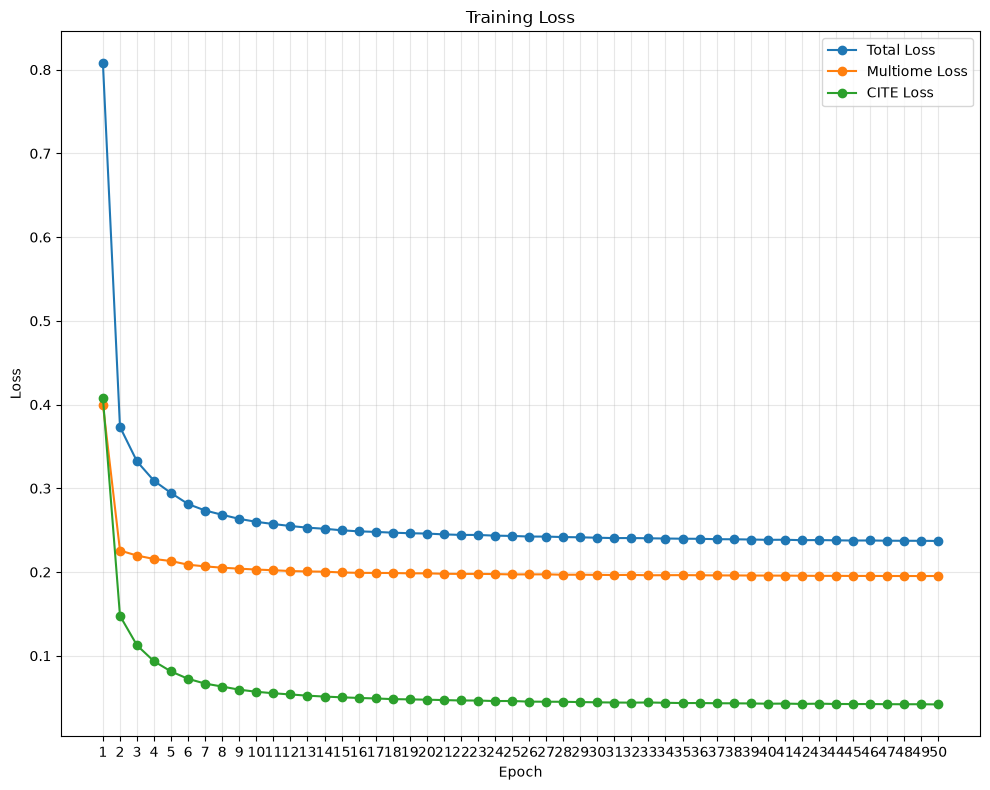

In [11]:
import os
import matplotlib.pyplot as plt
import torch

save_dir = "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/Diffusion"
os.makedirs(save_dir, exist_ok=True)

torch.save(
    model.state_dict(),
    os.path.join(save_dir, "unified_diffusion_model.pt")
)

epochs = range(1, 51)

total_losses = [
    0.807554, 0.373368, 0.332057, 0.308909, 0.294314,
    0.281139, 0.273483, 0.268358, 0.263471, 0.259960,
    0.257332, 0.254955, 0.253008, 0.251682, 0.249867,
    0.248614, 0.247936, 0.247016, 0.246345, 0.245966,
    0.244969, 0.244344, 0.244296, 0.243466, 0.243119,
    0.242382, 0.242341, 0.241777, 0.241481, 0.240982,
    0.240541, 0.240589, 0.240313, 0.240028, 0.239808,
    0.239695, 0.239228, 0.239116, 0.238853, 0.238454,
    0.238575, 0.238040, 0.238185, 0.237862, 0.237632,
    0.237694, 0.237413, 0.237325, 0.237317, 0.237112
]

multiome_losses = [
    0.399912, 0.225686, 0.219658, 0.215587, 0.213098,
    0.208748, 0.206747, 0.205170, 0.204008, 0.202967,
    0.202140, 0.201194, 0.200676, 0.200428, 0.199500,
    0.199013, 0.198944, 0.198814, 0.198453, 0.198447,
    0.197906, 0.197783, 0.197786, 0.197577, 0.197140,
    0.197196, 0.197235, 0.196765, 0.196805, 0.196609,
    0.196402, 0.196596, 0.196123, 0.196208, 0.196317,
    0.196151, 0.195969, 0.195927, 0.195829, 0.195740,
    0.195714, 0.195576, 0.195401, 0.195467, 0.195311,
    0.195365, 0.195259, 0.195254, 0.195219, 0.195271
]

cite_losses = [
    0.407642, 0.147682, 0.112399, 0.093322, 0.081216,
    0.072391, 0.066736, 0.063188, 0.059464, 0.056994,
    0.055192, 0.053761, 0.052332, 0.051254, 0.050368,
    0.049601, 0.048992, 0.048203, 0.047892, 0.047519,
    0.047063, 0.046561, 0.046511, 0.045888, 0.045979,
    0.045187, 0.045106, 0.045012, 0.044676, 0.044373,
    0.044140, 0.043994, 0.044190, 0.043821, 0.043492,
    0.043544, 0.043259, 0.043189, 0.043025, 0.042714,
    0.042861, 0.042465, 0.042784, 0.042396, 0.042322,
    0.042330, 0.042154, 0.042071, 0.042097, 0.041841
]

plt.figure(figsize=(10, 8))

plt.plot(
    epochs,
    total_losses,
    marker="o",
    label="Total Loss"
)

plt.plot(
    epochs,
    multiome_losses,
    marker="o",
    label="Multiome Loss"
)

plt.plot(
    epochs,
    cite_losses,
    marker="o",
    label="CITE Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(save_dir, "training_loss.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
import inspect

print(inspect.signature(MultimodalDiffusionModel))

(multi_gene_dim, cite_gene_dim, protein_dim)


In [47]:
print("RNA")
print(z_rna.mean().item())
print(z_rna.std().item())
print(z_rna.min().item())
print(z_rna.max().item())

print("\nProtein")
print(z_protein_denoised.mean().item())
print(z_protein_denoised.std().item())
print(z_protein_denoised.min().item())
print(z_protein_denoised.max().item())

rna_var = z_rna.detach().cpu().numpy().var(axis=0)
protein_var = z_protein_denoised.detach().cpu().numpy().var(axis=0)

print("RNA latent variance")
print("mean:", rna_var.mean())
print("median:", np.median(rna_var))
print("max:", rna_var.max())

print("\nProtein latent variance")
print("mean:", protein_var.mean())
print("median:", np.median(protein_var))
print("max:", protein_var.max())

RNA
-0.001527479849755764
0.04806700348854065
-0.20498688519001007
0.3208298087120056

Protein
0.0157195795327425
0.07830222696065903
-0.17183440923690796
0.1994624137878418
RNA latent variance
mean: 4.666208e-05
median: 3.0929863e-05
max: 0.00028178073

Protein latent variance
mean: 0.000117691015
median: 0.00011550126
max: 0.0001469443


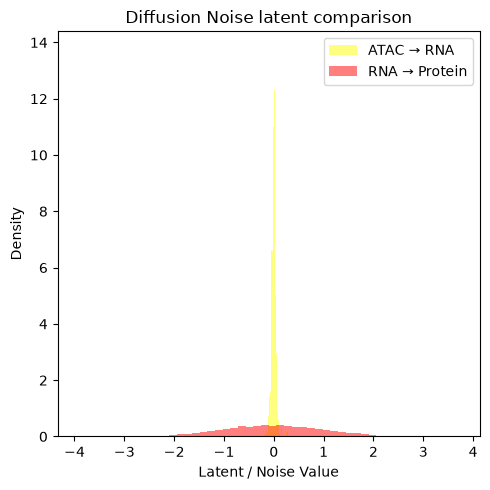

In [65]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

with torch.no_grad():
    z_rna = model.cite_rna_encoder(rna)

    z_protein = z_rna.clone()

    protein_noise = torch.randn_like(z_protein[..., :64])

    z_protein = z_protein[..., :64] + protein_noise

rna_values = z_rna.cpu().numpy().ravel()
protein_noise_values = protein_noise.cpu().numpy().ravel()

plt.figure(figsize=(5, 5))

plt.hist(
    rna_values,
    bins=50,
    density=True,
    alpha=0.5,
    color="yellow"
)

plt.hist(
    protein_noise_values,
    bins=50,
    density=True,
    alpha=0.5,
    color="red"
)

legend_elements = [
    Patch(facecolor="yellow", alpha=0.5, label="ATAC → RNA"),
    Patch(facecolor="red", alpha=0.5, label="RNA → Protein")
]

plt.xlabel("Latent / Noise Value")
plt.ylabel("Density")
plt.title("Diffusion Noise latent comparison")
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [56]:
@torch.no_grad()
def sample_protein_latent(model, z_rna):
    model.eval()
    batch_size_current = z_rna.shape[0]

    z = torch.randn(
        batch_size_current,
        protein_latent_dim,
        device=device
    )

    for step in reversed(range(num_diffusion_steps)):
        t = torch.full(
            (batch_size_current,),
            step,
            device=device,
            dtype=torch.long
        )

        beta_t = schedule.beta[step]
        alpha_t = schedule.alpha[step]
        alpha_bar_t = schedule.alpha_bar[step]

        noise_pred = model.rna_to_protein_diffusion(
            z,
            z_rna,
            t
        )

        z = (
            1.0 / torch.sqrt(alpha_t)
        ) * (
            z -
            (
                beta_t /
                torch.sqrt(1.0 - alpha_bar_t)
            ) * noise_pred
        )

        if step > 0:
            noise = torch.randn_like(z)
            z = z + torch.sqrt(beta_t) * noise

    return z

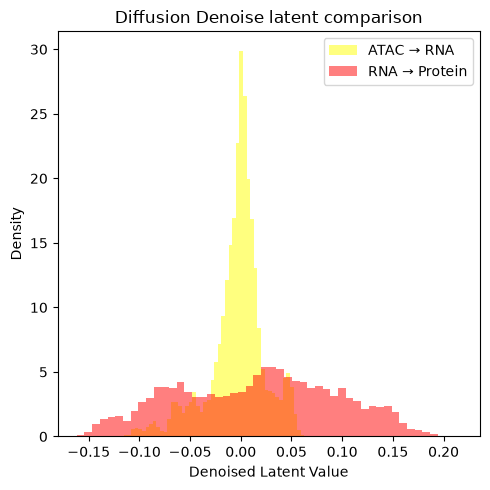

In [66]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

with torch.no_grad():
    if isinstance(peak, torch.Tensor):
        peak_tensor = peak.to(device)
    else:
        if hasattr(peak, "toarray"):
            peak = peak.toarray()
        peak_tensor = torch.tensor(
            np.asarray(peak, dtype=np.float32),
            device=device
        )

    if isinstance(rna, torch.Tensor):
        rna_tensor = rna.to(device)
    else:
        if hasattr(rna, "toarray"):
            rna = rna.toarray()
        rna_tensor = torch.tensor(
            np.asarray(rna, dtype=np.float32),
            device=device
        )

    z_atac = model.encode_atac(peak_tensor)
    z_rna_denoised = sample_rna_latent(model, z_atac)

    z_rna = model.cite_rna_encoder(rna_tensor)
    z_protein_denoised = sample_protein_latent(model, z_rna)

rna_denoised_values = z_rna_denoised.cpu().numpy().ravel()
protein_denoised_values = z_protein_denoised.cpu().numpy().ravel()

plt.figure(figsize=(5, 5))

plt.hist(
    rna_denoised_values,
    bins=50,
    density=True,
    alpha=0.5,
    color="yellow"
)

plt.hist(
    protein_denoised_values,
    bins=50,
    density=True,
    alpha=0.5,
    color="red"
)

legend_elements = [
    Patch(facecolor="yellow", alpha=0.5, label="ATAC → RNA"),
    Patch(facecolor="red", alpha=0.5, label="RNA → Protein")
]

plt.xlabel("Denoised Latent Value")
plt.ylabel("Density")
plt.title("Diffusion Denoise latent comparison")
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [61]:
import torch
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def trace_rna_diffusion(model, z_atac):
    model.eval()

    batch_size_current = z_atac.shape[0]

    z = torch.randn(
        batch_size_current,
        latent_dim,
        device=device
    )

    steps = []
    noise_variances = []
    denoise_variances = []

    for step in reversed(range(num_diffusion_steps)):
        t = torch.full(
            (batch_size_current,),
            step,
            device=device,
            dtype=torch.long
        )

        beta_t = schedule.beta[step]
        alpha_t = schedule.alpha[step]
        alpha_bar_t = schedule.alpha_bar[step]

        noise_pred = model.atac_to_rna_diffusion(
            z,
            z_atac,
            t
        )

        z_denoised = (
            1.0 / torch.sqrt(alpha_t)
        ) * (
            z -
            (
                beta_t /
                torch.sqrt(1.0 - alpha_bar_t)
            ) * noise_pred
        )

        noise_variances.append(
            z.var(dim=0).mean().item()
        )

        denoise_variances.append(
            z_denoised.var(dim=0).mean().item()
        )

        steps.append(step)

        z = z_denoised

        if step > 0:
            noise = torch.randn_like(z)
            z = z + torch.sqrt(beta_t) * noise

    return (
        np.array(steps),
        np.array(noise_variances),
        np.array(denoise_variances)
    )


@torch.no_grad()
def trace_protein_diffusion(model, z_rna):
    model.eval()

    batch_size_current = z_rna.shape[0]

    z = torch.randn(
        batch_size_current,
        protein_latent_dim,
        device=device
    )

    steps = []
    noise_variances = []
    denoise_variances = []

    for step in reversed(range(num_diffusion_steps)):
        t = torch.full(
            (batch_size_current,),
            step,
            device=device,
            dtype=torch.long
        )

        beta_t = schedule.beta[step]
        alpha_t = schedule.alpha[step]
        alpha_bar_t = schedule.alpha_bar[step]

        noise_pred = model.rna_to_protein_diffusion(
            z,
            z_rna,
            t
        )

        z_denoised = (
            1.0 / torch.sqrt(alpha_t)
        ) * (
            z -
            (
                beta_t /
                torch.sqrt(1.0 - alpha_bar_t)
            ) * noise_pred
        )

        noise_variances.append(
            z.var(dim=0).mean().item()
        )

        denoise_variances.append(
            z_denoised.var(dim=0).mean().item()
        )

        steps.append(step)

        z = z_denoised

        if step > 0:
            noise = torch.randn_like(z)
            z = z + torch.sqrt(beta_t) * noise

    return (
        np.array(steps),
        np.array(noise_variances),
        np.array(denoise_variances)
    )


with torch.no_grad():
    if isinstance(peak, torch.Tensor):
        peak_tensor = peak.to(device)
    else:
        if hasattr(peak, "toarray"):
            peak = peak.toarray()
        peak_tensor = torch.tensor(
            np.asarray(peak, dtype=np.float32),
            device=device
        )

    if isinstance(rna, torch.Tensor):
        rna_tensor = rna.to(device)
    else:
        if hasattr(rna, "toarray"):
            rna = rna.toarray()
        rna_tensor = torch.tensor(
            np.asarray(rna, dtype=np.float32),
            device=device
        )

    z_atac = model.encode_atac(peak_tensor)
    z_rna = model.cite_rna_encoder(rna_tensor)

rna_steps, rna_noise_var, rna_denoise_var = trace_rna_diffusion(
    model,
    z_atac
)

protein_steps, protein_noise_var, protein_denoise_var = trace_protein_diffusion(
    model,
    z_rna
)

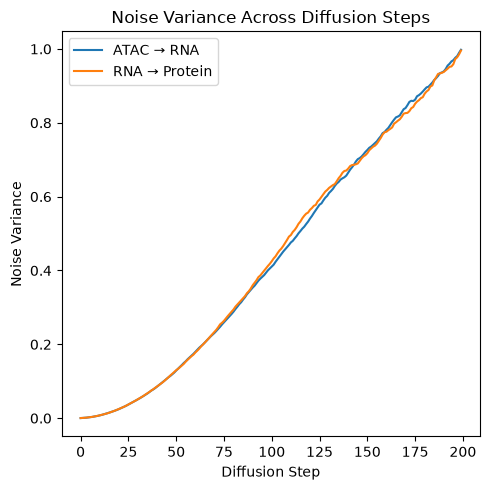

In [67]:
plt.figure(figsize=(5, 5))

plt.plot(
    rna_steps,
    rna_noise_var,
    label="ATAC → RNA"
)

plt.plot(
    protein_steps,
    protein_noise_var,
    label="RNA → Protein"
)

plt.xlabel("Diffusion Step")
plt.ylabel("Noise Variance")
plt.title("Noise Variance Across Diffusion Steps")
plt.legend()
plt.tight_layout()
plt.show()

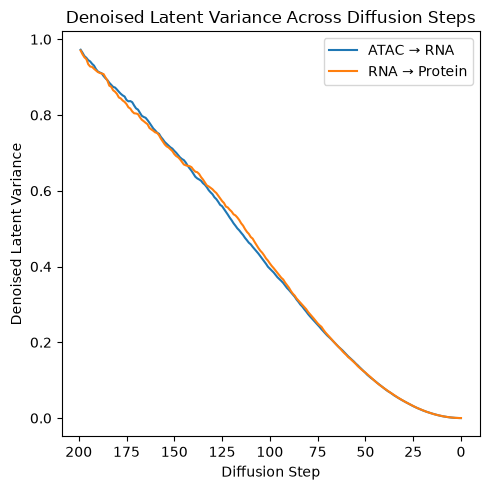

In [68]:
plt.figure(figsize=(5, 5))

plt.plot(
    rna_steps,
    rna_denoise_var,
    label="ATAC → RNA"
)

plt.plot(
    protein_steps,
    protein_denoise_var,
    label="RNA → Protein"
)

plt.xlabel("Diffusion Step")
plt.ylabel("Denoised Latent Variance")
plt.title("Denoised Latent Variance Across Diffusion Steps")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

In [78]:
import numpy as np
import torch

batch_size_eval = 128

rna_squared_errors = []
protein_squared_errors = []

model.eval()

with torch.no_grad():

    peak_data = train_multi.layers["peak_sum"]
    rna_gt_data = train_multi.layers["rna"]

    for start in range(0, train_multi.n_obs, batch_size_eval):
        end = min(start + batch_size_eval, train_multi.n_obs)

        peak_batch = peak_data[start:end]
        rna_gt_batch = rna_gt_data[start:end]

        if hasattr(peak_batch, "toarray"):
            peak_batch = peak_batch.toarray()

        if hasattr(rna_gt_batch, "toarray"):
            rna_gt_batch = rna_gt_batch.toarray()

        peak_batch = torch.tensor(
            np.asarray(peak_batch, dtype=np.float32),
            device=device
        )

        rna_gt_batch = torch.tensor(
            np.asarray(rna_gt_batch, dtype=np.float32),
            device=device
        )

        z_atac = model.encode_atac(peak_batch)
        z_rna_pred = sample_rna_latent(model, z_atac)
        rna_pred = model.multi_rna_decoder(z_rna_pred)

        mse = (
            (rna_pred - rna_gt_batch) ** 2
        ).mean(dim=1)

        rna_squared_errors.append(
            mse.cpu().numpy()
        )

        del peak_batch, rna_gt_batch
        del z_atac, z_rna_pred, rna_pred, mse

        torch.cuda.empty_cache()

    cite_rna_data = train_cite_rna_unique.X
    protein_gt_data = train_cite["protein"].X

    for start in range(0, train_cite_rna_unique.n_obs, batch_size_eval):
        end = min(start + batch_size_eval, train_cite_rna_unique.n_obs)

        rna_batch = cite_rna_data[start:end]
        protein_gt_batch = protein_gt_data[start:end]

        if hasattr(rna_batch, "toarray"):
            rna_batch = rna_batch.toarray()

        if hasattr(protein_gt_batch, "toarray"):
            protein_gt_batch = protein_gt_batch.toarray()

        rna_batch = torch.tensor(
            np.asarray(rna_batch, dtype=np.float32),
            device=device
        )

        protein_gt_batch = torch.tensor(
            np.asarray(protein_gt_batch, dtype=np.float32),
            device=device
        )

        z_rna = model.encode_cite_rna(rna_batch)
        z_protein_pred = sample_protein_latent(model, z_rna)
        protein_pred = model.protein_decoder(z_protein_pred)

        mse = (
            (protein_pred - protein_gt_batch) ** 2
        ).mean(dim=1)

        protein_squared_errors.append(
            mse.cpu().numpy()
        )

        del rna_batch, protein_gt_batch
        del z_rna, z_protein_pred, protein_pred, mse

        torch.cuda.empty_cache()

rna_squared_errors = np.concatenate(rna_squared_errors)
protein_squared_errors = np.concatenate(protein_squared_errors)

rna_rmse = np.sqrt(np.mean(rna_squared_errors))
protein_rmse = np.sqrt(np.mean(protein_squared_errors))

print(f"ATAC → RNA RMSE: {rna_rmse:.6f}")
print(f"RNA → Protein RMSE: {protein_rmse:.6f}")

ATAC → RNA RMSE: 1.462606
RNA → Protein RMSE: 2.207251


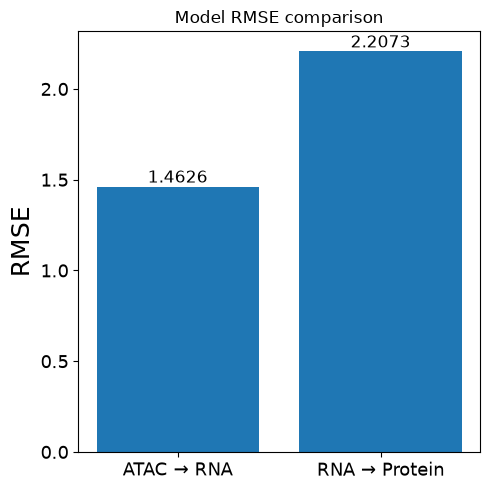

In [83]:
import matplotlib.pyplot as plt

models = [
    "ATAC → RNA",
    "RNA → Protein"
]

rmse_values = [
    rna_rmse,
    protein_rmse
]

fig, ax = plt.subplots(figsize=(5, 5))

bars = ax.bar(
    models,
    rmse_values
)

ax.set_ylabel("RMSE")
ax.set_title("Model RMSE comparison")

ax.tick_params(
    axis="both",
    labelsize=13
)
ax.set_ylabel("RMSE", fontsize=18)
for bar, value in zip(bars, rmse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.tight_layout()
plt.show()

# Diffusion Predict

In [12]:
@torch.no_grad()
def predict_rna_from_atac(model, peak):
    z_atac = model.atac_encoder(peak)

    z_rna = sample_rna_latent(
        model,
        z_atac
    )

    rna = model.multi_rna_decoder(z_rna)

    return rna


@torch.no_grad()
def predict_protein_from_rna(model, rna):
    z_rna = model.cite_rna_encoder(rna)

    z_protein = sample_protein_latent(
        model,
        z_rna
    )

    protein = model.protein_decoder(z_protein)

    return protein

In [13]:
import os
import numpy as np
import torch
import anndata as ad

device = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

save_dir = "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/Diffusion"

model_path = os.path.join(
    save_dir,
    "unified_diffusion_model.pt"
)

model.load_state_dict(
    torch.load(
        model_path,
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print("Model loaded")
print(
    "Device:",
    next(model.parameters()).device
)


cite_keep = ~train_cite["rna"].var_names.duplicated(
    keep="first"
)

train_cite_rna_unique = train_cite["rna"][
    :,
    cite_keep
].copy()

test_rna_keep = ~test_rna.var_names.duplicated(
    keep="first"
)

test_rna = test_rna[
    :,
    test_rna_keep
].copy()


train_multi_genes = train_multi.var_names.to_numpy()

train_cite_genes = train_cite_rna_unique.var_names.to_numpy()


test_atac = test_atac[
    :,
    train_multi_genes
].copy()

test_rna = test_rna[
    :,
    train_cite_genes
].copy()


assert np.array_equal(
    test_atac.var_names,
    train_multi.var_names
)

assert np.array_equal(
    test_rna.var_names,
    train_cite_rna_unique.var_names
)


print(
    "ATAC feature order:",
    np.array_equal(
        test_atac.var_names,
        train_multi.var_names
    )
)

print(
    "RNA feature order:",
    np.array_equal(
        test_rna.var_names,
        train_cite_rna_unique.var_names
    )
)

print(
    "Multiome features:",
    train_multi.n_vars
)

print(
    "CITE RNA features:",
    train_cite_rna_unique.n_vars
)

print(
    "Test RNA features:",
    test_rna.n_vars
)


batch_size = 128


peak = test_atac.layers["peak_sum"]

if hasattr(peak, "toarray"):
    peak = peak.toarray()

peak = np.asarray(
    peak,
    dtype=np.float32
)


pred_rna_list = []

with torch.no_grad():

    for start in range(
        0,
        len(test_atac),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(test_atac)
        )

        peak_batch = torch.tensor(
            peak[start:end],
            dtype=torch.float32,
            device=device
        )

        z_atac = model.encode_atac(
            peak_batch
        )

        z_rna = sample_rna_latent(
            model,
            z_atac
        )

        pred_rna_batch = model.multi_rna_decoder(
            z_rna
        )

        pred_rna_list.append(
            pred_rna_batch.cpu().numpy()
        )


pred_rna = np.concatenate(
    pred_rna_list,
    axis=0
)


pred_rna_adata = ad.AnnData(
    X=pred_rna,
    obs=test_atac.obs.copy(),
    var=train_multi.var.copy()
)

print(
    "Predicted RNA:",
    pred_rna_adata.shape
)


rna = test_rna.X

if hasattr(rna, "toarray"):
    rna = rna.toarray()

rna = np.asarray(
    rna,
    dtype=np.float32
)


pred_protein_list = []

with torch.no_grad():

    for start in range(
        0,
        len(test_rna),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(test_rna)
        )

        rna_batch = torch.tensor(
            rna[start:end],
            dtype=torch.float32,
            device=device
        )

        z_rna = model.encode_cite_rna(
            rna_batch
        )

        z_protein = sample_protein_latent(
            model,
            z_rna
        )

        pred_protein_batch = model.protein_decoder(
            z_protein
        )

        pred_protein_list.append(
            pred_protein_batch.cpu().numpy()
        )


pred_protein = np.concatenate(
    pred_protein_list,
    axis=0
)


pred_protein_adata = ad.AnnData(
    X=pred_protein,
    obs=test_rna.obs.copy(),
    var=train_cite["protein"].var.copy()
)


print(
    "Predicted Protein:",
    pred_protein_adata.shape
)


rna_path = os.path.join(
    save_dir,
    "test_predicted_rna.h5ad"
)

protein_path = os.path.join(
    save_dir,
    "test_predicted_protein.h5ad"
)


pred_rna_adata.write_h5ad(
    rna_path
)

pred_protein_adata.write_h5ad(
    protein_path
)


print("Saved:")
print(rna_path)
print(protein_path)

Model loaded
Device: cuda:0
ATAC feature order: True
RNA feature order: True
Multiome features: 23289
CITE RNA features: 21967
Test RNA features: 21967
Predicted RNA: (55935, 23289)
Predicted Protein: (55679, 140)
Saved:
/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/Diffusion/test_predicted_rna.h5ad
/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/Diffusion/test_predicted_protein.h5ad


In [33]:
import pandas as pd

evaluation_ids = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/evaluation_ids.csv"
)

sample_submission = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/sample_submission.csv"
)

In [37]:
import pandas as pd
import requests
import time

evaluation_ids = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/evaluation_ids.csv"
)

gtf_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/baseline/gencode.v44.annotation.gtf.gz"

gtf = pd.read_csv(
    gtf_path,
    sep="\t",
    comment="#",
    header=None,
    names=[
        "chr", "source", "feature", "start", "end",
        "score", "strand", "frame", "attribute"
    ]
)

gene_gtf = gtf[gtf["feature"] == "gene"].copy()

gene_gtf["gene_id"] = (
    gene_gtf["attribute"]
    .str.extract(r'gene_id "([^"]+)"')[0]
    .str.split(".")
    .str[0]
)

gene_gtf["gene_name"] = (
    gene_gtf["attribute"]
    .str.extract(r'gene_name "([^"]+)"')[0]
)

gene_map = (
    gene_gtf
    .dropna(subset=["gene_id", "gene_name"])
    .drop_duplicates("gene_id")
    .set_index("gene_id")["gene_name"]
    .to_dict()
)

mask = evaluation_ids["gene_id"].astype(str).str.match(
    r"^ENSG\d+",
    na=False
)

ensg_ids = (
    evaluation_ids.loc[mask, "gene_id"]
    .astype(str)
    .str.extract(r"^(ENSG\d+)", expand=False)
)

mapped_genes = ensg_ids.map(gene_map)

evaluation_ids.loc[mask, "gene_id"] = mapped_genes

remaining_mask = (
    evaluation_ids["gene_id"]
    .astype(str)
    .str.match(r"^ENSG\d+$", na=False)
)

remaining_ids = (
    evaluation_ids.loc[remaining_mask, "gene_id"]
    .astype(str)
    .unique()
)

print("GTF에서 변환되지 않은 ENSG:", len(remaining_ids))

ensembl_map = {}

url = "https://rest.ensembl.org/lookup/id"

for i in range(0, len(remaining_ids), 1000):
    batch = remaining_ids[i:i + 1000]

    response = requests.post(
        url,
        params={
            "species": "homo_sapiens",
            "object_type": "gene"
        },
        headers={
            "Content-Type": "application/json",
            "Accept": "application/json"
        },
        json={
            "ids": batch.tolist()
        }
    )

    response.raise_for_status()

    result = response.json()

    for gene_id, info in result.items():
        if isinstance(info, dict):
            gene_name = info.get("display_name")

            if gene_name:
                ensembl_map[gene_id] = gene_name

    print(
        f"{min(i + 1000, len(remaining_ids))} / {len(remaining_ids)}"
    )

    time.sleep(0.1)

evaluation_ids.loc[remaining_mask, "gene_id"] = (
    evaluation_ids.loc[remaining_mask, "gene_id"]
    .map(ensembl_map)
    .fillna(evaluation_ids.loc[remaining_mask, "gene_id"])
)

unmapped = evaluation_ids.loc[
    evaluation_ids["gene_id"].astype(str).str.match(
        r"^ENSG\d+$",
        na=False
    ),
    "gene_id"
].unique()

print("최종 변환되지 않은 ENSG:", len(unmapped))
print(unmapped[:20])

print(evaluation_ids.loc[mask, ["gene_id"]].tail())

GTF에서 변환되지 않은 ENSG: 4715
1000 / 4715
2000 / 4715
3000 / 4715
4000 / 4715
4715 / 4715
최종 변환되지 않은 ENSG: 4342
['ENSG00000273381' 'ENSG00000286658' 'ENSG00000283839' 'ENSG00000270174'
 'ENSG00000267044' 'ENSG00000281195' 'ENSG00000248758' 'ENSG00000260000'
 'ENSG00000235880' 'ENSG00000259422' 'ENSG00000227857' 'ENSG00000236854'
 'ENSG00000255829' 'ENSG00000259865' 'ENSG00000288021' 'ENSG00000287045'
 'ENSG00000271882' 'ENSG00000230333' 'ENSG00000285530' 'ENSG00000288067']
         gene_id
65744175  RPS15A
65744176   PDZD7
65744177   DCDC1
65744178  CUEDC2
65744179   TAF1D


In [43]:
cell_ids = evaluation_ids["cell_id"].astype(str)
gene_ids = evaluation_ids["gene_id"].astype(str)

rna_cells = pd.Series(
    np.arange(pred_rna_adata.n_obs),
    index=pred_rna_adata.obs_names.astype(str)
)
rna_genes = pd.Series(
    np.arange(pred_rna_adata.n_vars),
    index=pred_rna_adata.var_names.astype(str)
)

protein_cells = pd.Series(
    np.arange(pred_protein_adata.n_obs),
    index=pred_protein_adata.obs_names.astype(str)
)
protein_genes = pd.Series(
    np.arange(pred_protein_adata.n_vars),
    index=pred_protein_adata.var_names.astype(str)
)

rna_r = cell_ids.map(rna_cells)
rna_c = gene_ids.map(rna_genes)

protein_r = cell_ids.map(protein_cells)
protein_c = gene_ids.map(protein_genes)

rna_valid = rna_r.notna() & rna_c.notna()
protein_valid = protein_r.notna() & protein_c.notna()

target = np.zeros(len(evaluation_ids), dtype=np.float32)

if rna_valid.any():
    r = rna_r[rna_valid].to_numpy(dtype=np.int64)
    c = rna_c[rna_valid].to_numpy(dtype=np.int64)
    target[rna_valid.to_numpy()] = np.asarray(
        pred_rna_adata.X[r, c]
    ).ravel()

if protein_valid.any():
    protein_only = (~rna_valid) & protein_valid
    r = protein_r[protein_only].to_numpy(dtype=np.int64)
    c = protein_c[protein_only].to_numpy(dtype=np.int64)
    target[protein_only.to_numpy()] = np.asarray(
        pred_protein_adata.X[r, c]
    ).ravel()

sample_submission["target"] = target

matched = rna_valid | protein_valid
total = len(evaluation_ids)

print("전체:", total)
print("RNA 매칭:", rna_valid.sum(), f"({rna_valid.sum() / total * 100:.2f}%)")
print("Protein 매칭:", protein_valid.sum(), f"({protein_valid.sum() / total * 100:.2f}%)")
print("매칭 성공:", matched.sum(), f"({matched.sum() / total * 100:.2f}%)")
print("없는 데이터:", (~matched).sum(), f"({(~matched).sum() / total * 100:.2f}%)")

전체: 65744180
RNA 매칭: 57689787 (87.75%)
Protein 매칭: 6812820 (10.36%)
매칭 성공: 64502607 (98.11%)
없는 데이터: 1241573 (1.89%)


In [47]:
eval_genes = set(evaluation_ids["gene_id"].astype(str))

rna_genes_set = set(pred_rna_adata.var_names.astype(str))
protein_genes_set = set(pred_protein_adata.var_names.astype(str))

rna_eval_only = sorted(eval_genes - rna_genes_set)
rna_object_only = sorted(rna_genes_set - eval_genes)

protein_eval_only = sorted(eval_genes - protein_genes_set)
protein_object_only = sorted(protein_genes_set - eval_genes)

print("===== RNA =====")
print("evaluation_ids에만 있는 gene:", len(rna_eval_only))
print(rna_eval_only)

print("\npred_rna_adata에만 있는 gene:", len(rna_object_only))
print(rna_object_only)

print("\n===== Protein =====")
print("evaluation_ids에만 있는 gene:", len(protein_eval_only))
print(protein_eval_only)

print("\npred_protein_adata에만 있는 gene:", len(protein_object_only))
print(protein_object_only)

===== RNA =====
evaluation_ids에만 있는 gene: 476
['AASDHPPT-AS1', 'ABHD16B-AS1', 'ACER3-AS1', 'ACTN4-AS1', 'ADAMTS10-AS1', 'ADD2-AS1', 'ADK-AS1', 'AK2-AS1', 'AMN1-AS1', 'AMPD2-AS1', 'ANKRD27-AS1', 'AOPEP-AS1', 'APC2-AS1', 'ARID1B-AS1', 'ATF7-AS1', 'ATP5IF1-AS1', 'ATP9B-AS1', 'AZIN1-AS2', 'BABAM2-AS2', 'BAG5-AS1', 'BCAT1-AS1', 'BCL6-AS1', 'BICRA-AS2', 'BLK-AS1', 'C16orf46-AS1', 'C16orf46-DT', 'C1orf202', 'C7orf78', 'CABYR-AS1', 'CACNB2-AS1', 'CACNB2-AS2', 'CALHM2-AS1', 'CASZ1-AS1', 'CAV2-DT', 'CBX7-AS1', 'CCDC146-AS1', 'CCT5-AS1', 'CD103', 'CD105', 'CD107a', 'CD112', 'CD115', 'CD119', 'CD11a', 'CD11b', 'CD11c', 'CD122', 'CD123', 'CD124', 'CD127', 'CD13', 'CD134', 'CD137', 'CD141', 'CD142', 'CD146', 'CD152', 'CD154', 'CD155', 'CD158', 'CD158b', 'CD158e1', 'CD16', 'CD161', 'CD162', 'CD169', 'CD172a', 'CD18', 'CD185', 'CD192', 'CD194', 'CD195', 'CD196', 'CD1c', 'CD1d', 'CD20', 'CD21', 'CD223', 'CD224', 'CD23', 'CD25', 'CD26', 'CD268', 'CD270', 'CD272', 'CD278', 'CD279', 'CD29', 'CD3', 'CD303'

In [53]:
sample_submission

,row_id,target
0,0,-0.449665
1,1,-0.123512
2,2,0.156334
3,3,2.257216
4,4,4.247107
...,...,...
65744175,65744175,6.467713
65744176,65744176,0.090155
65744177,65744177,0.045790
65744178,65744178,1.132967


In [54]:
B = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/sample_submission.csv"
)

B

,row_id,target
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0
...,...,...
65744175,65744175,0.0
65744176,65744176,0.0
65744177,65744177,0.0
65744178,65744178,0.0


In [44]:
sample_submission

,row_id,target
0,0,-0.449665
1,1,-0.123512
2,2,0.156334
3,3,2.257216
4,4,4.247107
...,...,...
65744175,65744175,6.467713
65744176,65744176,0.090155
65744177,65744177,0.045790
65744178,65744178,1.132967


In [45]:
sample_submission.to_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Multimodal_Single-Cell_Integration/submission/sample_submission.csv",
    index=False
)

In [52]:
sample_submission

,row_id,target
0,0,-0.449665
1,1,-0.123512
2,2,0.156334
3,3,2.257216
4,4,4.247107
...,...,...
65744175,65744175,6.467713
65744176,65744176,0.090155
65744177,65744177,0.045790
65744178,65744178,1.132967
